In [104]:
import pandas as pd
import geopandas as gpd
df = pd.read_csv('data/2015_Street_Tree_Census_-_Tree_Data_20260227.csv')

In [106]:
df

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,"4,073,900",New York,40.723092,-73.844215,"1,027,431.148","202,756.7687",29.0,739,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,"4,097,300",New York,40.794111,-73.818679,"1,034,455.701","228,644.8374",19.0,973,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"3,044,900",New York,40.717581,-73.936608,"1,001,822.831","200,716.8913",34.0,449,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,"3,044,900",New York,40.713537,-73.934456,"1,002,420.358","199,244.2531",34.0,449,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Good,Tilia americana,American linden,...,"3,016,500",New York,40.666778,-73.975979,"990,913.775","182,202.426",39.0,165,3025654.0,3.010850e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683783,155433,217978,08/18/2015,25,0,OnCurb,Alive,Good,Quercus palustris,pin oak,...,"3,051,900",New York,40.713211,-73.954944,"996,740.686","199,121.6363",34.0,519,3062513.0,3.023690e+09
683784,183795,348185,08/29/2015,7,0,OnCurb,Alive,Good,Cladrastis kentukea,Kentucky yellowwood,...,"4,070,700",New York,40.715194,-73.856650,"1,023,989.074","199,873.6475",29.0,707,4075448.0,4.031810e+09
683785,166161,401670,08/22/2015,12,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,"5,020,100",New York,40.620762,-74.136517,"946,351.4104","165,466.0763",50.0,201,5011657.0,5.004080e+09
683786,184028,504204,08/29/2015,9,0,OnCurb,Alive,Good,Acer rubrum,red maple,...,"2,023,502",New York,40.850828,-73.903115,"1,011,053.646","249,271.9507",15.0,"23,502",2007757.0,2.028120e+09


In [108]:
df = df[df['status'] == 'Alive']

In [109]:
df.columns


Index(['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam',
       'curb_loc', 'status', 'health', 'spc_latin', 'spc_common', 'steward',
       'guards', 'sidewalk', 'user_type', 'problems', 'root_stone',
       'root_grate', 'root_other', 'trunk_wire', 'trnk_light', 'trnk_other',
       'brch_light', 'brch_shoe', 'brch_other', 'address', 'postcode',
       'zip_city', 'community board', 'borocode', 'borough', 'cncldist',
       'st_assem', 'st_senate', 'nta', 'nta_name', 'boro_ct', 'state',
       'latitude', 'longitude', 'x_sp', 'y_sp', 'council district',
       'census tract', 'bin', 'bbl'],
      dtype='object')

In [110]:
df = df.drop(columns=['problems', 'root_stone', 'root_grate', 'root_other', 'health', 'guards'])

In [111]:
df

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,spc_latin,spc_common,steward,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Acer rubrum,red maple,NaN,...,"4,073,900",New York,40.723092,-73.844215,"1,027,431.148","202,756.7687",29.0,739,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Quercus palustris,pin oak,NaN,...,"4,097,300",New York,40.794111,-73.818679,"1,034,455.701","228,644.8374",19.0,973,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Gleditsia triacanthos var. inermis,honeylocust,1or2,...,"3,044,900",New York,40.717581,-73.936608,"1,001,822.831","200,716.8913",34.0,449,3338310.0,3.028870e+09
3,204337,217969,09/05/2015,10,0,OnCurb,Alive,Gleditsia triacanthos var. inermis,honeylocust,NaN,...,"3,044,900",New York,40.713537,-73.934456,"1,002,420.358","199,244.2531",34.0,449,3338342.0,3.029250e+09
4,189565,223043,08/30/2015,21,0,OnCurb,Alive,Tilia americana,American linden,NaN,...,"3,016,500",New York,40.666778,-73.975979,"990,913.775","182,202.426",39.0,165,3025654.0,3.010850e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683783,155433,217978,08/18/2015,25,0,OnCurb,Alive,Quercus palustris,pin oak,NaN,...,"3,051,900",New York,40.713211,-73.954944,"996,740.686","199,121.6363",34.0,519,3062513.0,3.023690e+09
683784,183795,348185,08/29/2015,7,0,OnCurb,Alive,Cladrastis kentukea,Kentucky yellowwood,1or2,...,"4,070,700",New York,40.715194,-73.856650,"1,023,989.074","199,873.6475",29.0,707,4075448.0,4.031810e+09
683785,166161,401670,08/22/2015,12,0,OnCurb,Alive,Acer rubrum,red maple,NaN,...,"5,020,100",New York,40.620762,-74.136517,"946,351.4104","165,466.0763",50.0,201,5011657.0,5.004080e+09
683786,184028,504204,08/29/2015,9,0,OnCurb,Alive,Acer rubrum,red maple,NaN,...,"2,023,502",New York,40.850828,-73.903115,"1,011,053.646","249,271.9507",15.0,"23,502",2007757.0,2.028120e+09


In [112]:
df.columns

Index(['tree_id', 'block_id', 'created_at', 'tree_dbh', 'stump_diam',
       'curb_loc', 'status', 'spc_latin', 'spc_common', 'steward', 'sidewalk',
       'user_type', 'trunk_wire', 'trnk_light', 'trnk_other', 'brch_light',
       'brch_shoe', 'brch_other', 'address', 'postcode', 'zip_city',
       'community board', 'borocode', 'borough', 'cncldist', 'st_assem',
       'st_senate', 'nta', 'nta_name', 'boro_ct', 'state', 'latitude',
       'longitude', 'x_sp', 'y_sp', 'council district', 'census tract', 'bin',
       'bbl'],
      dtype='object')

In [113]:
df = df[['spc_common', 'latitude', 'longitude',  'curb_loc', 'steward', 'sidewalk', 'tree_dbh', ]]

In [114]:
df = df.dropna(subset=['sidewalk'])

In [115]:
distribution = df['spc_common'].value_counts()
distribution[:25]

df_species = df[df['spc_common'].isin(distribution[:25].index)]

In [116]:
final_df =  df_species.dropna()

In [117]:
final_df['curb_loc'].unique()

array(['OnCurb', 'OffsetFromCurb'], dtype=object)

In [118]:
df.to_csv('filtered_data.csv', index=False)

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [120]:
# 1. Load and Clean (Ensuring X and y have the same rows)
data = pd.read_csv('filtered_data.csv')
data = data.dropna(subset=['sidewalk']) # Drop NaNs from the whole df so X and y match

# 2. Define Features (X) and Target (y)
# Replace 'target_column' with the actual name of what you want to predict
target = 'sidewalk'
X = data.drop(columns=[target])
y = data[target]

# 3. First Split: Separate the Test set (15% of total)
# Remaining 85% goes to 'X_temp' and 'y_temp'
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 4. Second Split: Separate Temp into Train and Validation
# To get 15% of the total from the 85% remaining, we use ~17.6% (0.15 / 0.85)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")

Train size: 456781 | Val size: 97565 | Test size: 97826


In [124]:
data.columns

Index(['spc_common', 'latitude', 'longitude', 'curb_loc', 'steward',
       'sidewalk', 'tree_dbh'],
      dtype='object')

In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

categorical_features = ['spc_common', 'curb_loc', 'steward']
numerical_features = ['latitude', 'longitude', 'tree_dbh']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Leaves numerical columns as they are
)

# Define the Model Pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# 2. Train the Model
rf_model.fit(X_train, y_train)

KeyboardInterrupt: 

In [82]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_recall_curve, auc

In [83]:
val_preds = rf_model.predict(X_val)

# Calculate F1
# If your target is binary (e.g., 'Damage' vs 'NoDamage'), specify pos_label
f1 = f1_score(y_val, val_preds, pos_label='Damage')
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.4041


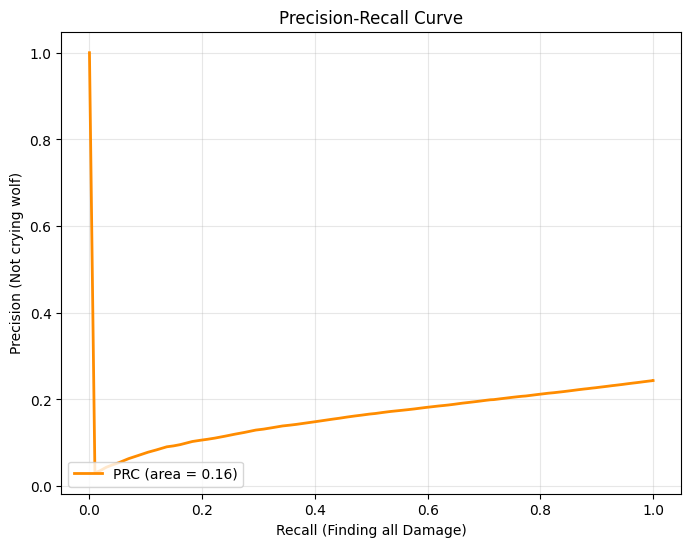

In [84]:
import matplotlib.pyplot as plt

# Get the probability scores for the 'Damage' class
# [:, 1] assumes 'Damage' is the second class in your encoder
y_scores = rf_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_scores, pos_label='Damage')
prc_auc = auc(recall, precision)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PRC (area = {prc_auc:.2f})', color='darkorange', lw=2)
plt.xlabel('Recall (Finding all Damage)')
plt.ylabel('Precision (Not crying wolf)')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    precision_score, recall_score, precision_recall_curve, auc
)

# 1. Setup Data & Label Encoding
# XGBoost requires y to be numeric (0, 1)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

# Identify the index for 'Damage' to use for scoring
# Assuming LabelEncoder assigns 0 to 'Damage' or 1. Let's find out:
pos_label_index = list(le.classes_).index('Damage')

# 2. Pipeline Setup
categorical_features = ['spc_common', 'curb_loc', 'steward']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

# Calculate ratio for scale_pos_weight (count of negative / count of positive)
ratio = (y_train == 'NoDamage').sum() / (y_train == 'Damage').sum()

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        scale_pos_weight=ratio,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# 3. Train & Predict (Validation)
xgb_pipeline.fit(X_train, y_train_enc)
val_probs = xgb_pipeline.predict_proba(X_val)[:, pos_label_index]
val_preds = xgb_pipeline.predict(X_val)

# 4. Metrics
print("--- Validation Set Scores ---")
print(f"Accuracy:  {accuracy_score(y_val_enc, val_preds):.4f}")
print(f"Precision: {precision_score(y_val_enc, val_preds, pos_label=pos_label_index):.4f}")
print(f"Recall:    {recall_score(y_val_enc, val_preds, pos_label=pos_label_index):.4f}")
print(f"F1-Score:  {f1_score(y_val_enc, val_preds, pos_label=pos_label_index):.4f}")

# PRC Calculation
precision, recall, _ = precision_recall_curve(y_val_enc, val_probs, pos_label=pos_label_index)
print(f"PRC AUC:   {auc(recall, precision):.4f}")

C:\Users\ds3\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Validation Set Scores ---
Accuracy:  0.7150
Precision: 0.7956
Recall:    0.0052
F1-Score:  0.0103
PRC AUC:   0.5010


In [129]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load and Clean Data
data = pd.read_csv('filtered_data.csv')
data = data.dropna(subset=['sidewalk'])

X = data.drop(columns=['sidewalk'])
y = data['sidewalk']

# 2. Encode Target (Crucial: Make sure 'Damage' is mapped to 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
pos_label_idx = list(le.classes_).index('Damage')

# If 'Damage' became 0, we invert it so 1 is always the positive "Damage" class
if pos_label_idx == 0:
    y_encoded = 1 - y_encoded

# 3. Stratified Train/Test Split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded
)

# 4. Define Pipeline
categorical_features = ['spc_common', 'curb_loc', 'steward']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)

# Calculate ratio for the training set
ratio = np.sum(y_train_val == 0) / np.sum(y_train_val == 1)

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        scale_pos_weight=ratio,
        learning_rate=0.05,
        max_depth=4,
        eval_metric='logloss',
        random_state=42
    ))
])

# 5. Multi-Metric Cross-Validation Setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scikit-learn uses 'average_precision' to calculate the PRC AUC
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'prc_auc': 'average_precision'
}

# 6. Run the Validation
print("Running 5-Fold Cross Validation... this might take a few seconds.")
cv_results = cross_validate(
    xgb_pipeline,
    X_train_val,
    y_train_val,
    cv=skf,
    scoring=scoring_metrics
)

# 7. Print the Aggregated Results
print("\n--- 5-Fold Cross-Validation Average Scores ---")
print(f"Accuracy:  {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"Precision: {cv_results['test_precision'].mean():.4f} (+/- {cv_results['test_precision'].std():.4f})")
print(f"Recall:    {cv_results['test_recall'].mean():.4f} (+/- {cv_results['test_recall'].std():.4f})")
print(f"F1-Score:  {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")
print(f"PRC AUC:   {cv_results['test_prc_auc'].mean():.4f} (+/- {cv_results['test_prc_auc'].std():.4f})")

Running 5-Fold Cross Validation... this might take a few seconds.

--- 5-Fold Cross-Validation Average Scores ---
Accuracy:  0.6327 (+/- 0.0021)
Precision: 0.4159 (+/- 0.0020)
Recall:    0.6910 (+/- 0.0036)
F1-Score:  0.5192 (+/- 0.0022)
PRC AUC:   0.4554 (+/- 0.0034)



=== FINAL TEST SET PERFORMANCE ===
              precision    recall  f1-score   support

   No Damage       0.83      0.61      0.70     69747
      Damage       0.42      0.69      0.52     28079

    accuracy                           0.63     97826
   macro avg       0.62      0.65      0.61     97826
weighted avg       0.71      0.63      0.65     97826



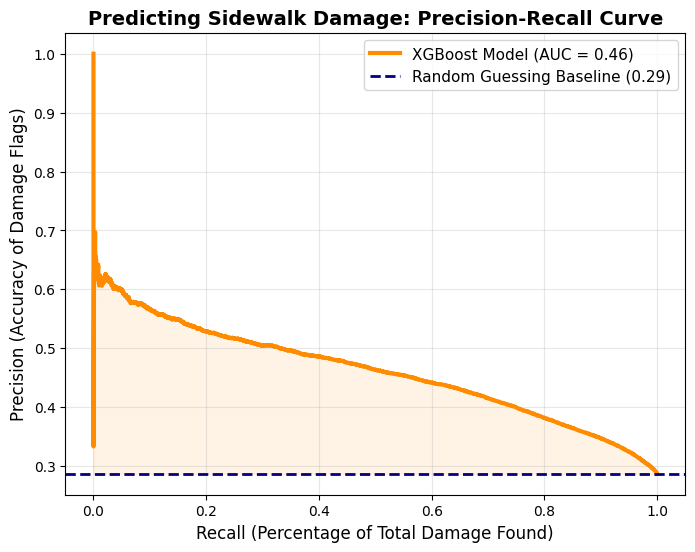


Graph saved as 'final_hackathon_prc.png'. Drag this into your slides!


In [130]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, classification_report

# 1. Fit the pipeline ONE LAST TIME on the full Train/Val set
xgb_pipeline.fit(X_train_val, y_train_val)

# 2. Get the probability scores for the Test Set
# ([:, 1] grabs the probability that the tree is a 1 / 'Damage')
test_probs = xgb_pipeline.predict_proba(X_test)[:, 1]
test_preds = xgb_pipeline.predict(X_test)

# 3. Print Final Test Set Metrics for your Slide
print("\n=== FINAL TEST SET PERFORMANCE ===")
print(classification_report(y_test, test_preds, target_names=['No Damage', 'Damage']))

# 4. Calculate Precision and Recall for the Graph
precision, recall, thresholds = precision_recall_curve(y_test, test_probs)
prc_auc = auc(recall, precision)

# Calculate the "Coin Flip" Baseline for YOUR specific data
baseline = sum(y_test) / len(y_test)

# 5. Plot the PRC for the Presentation
plt.figure(figsize=(8, 6))

# Plot the Model Curve
plt.plot(recall, precision, label=f'XGBoost Model (AUC = {prc_auc:.2f})',
         color='darkorange', lw=3)

# Plot the Coin Flip Baseline
plt.axhline(y=baseline, color='navy', linestyle='--', lw=2,
            label=f'Random Guessing Baseline ({baseline:.2f})')

# Formatting
plt.fill_between(recall, precision, baseline, alpha=0.1, color='darkorange')
plt.xlabel('Recall (Percentage of Total Damage Found)', fontsize=12)
plt.ylabel('Precision (Accuracy of Damage Flags)', fontsize=12)
plt.title('Predicting Sidewalk Damage: Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="upper right", fontsize=11)
plt.grid(True, alpha=0.3)

# Save the plot so you can drag-and-drop it into your presentation
plt.savefig('final_hackathon_prc.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraph saved as 'final_hackathon_prc.png'. Drag this into your slides!")

In [131]:
import joblib

# 1. Save the model to a file
joblib.dump(xgb_pipeline, 'sidewalk_damage_model.pkl')

print("✅ Model successfully saved as 'sidewalk_damage_model.pkl'!")

✅ Model successfully saved as 'sidewalk_damage_model.pkl'!
